1. Загрузка и предварительная обработка данных

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
import scipy.signal as signal
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

TRAIN_DATA = "MI-EEG-B9T_train.csv"
TRAIN_LABEL = "2class_MI_EEG_train_9.csv"
TEST_DATA = "MI-EEG-B9E_test.csv"
TEST_LABEL = "2class_MI_EEG_test_9.csv"

print("Загрузка данных...")
x_train = pd.read_csv(TRAIN_DATA, header=None).values
y_train = pd.read_csv(TRAIN_LABEL, header=None).values.ravel()
x_test = pd.read_csv(TEST_DATA, header=None).values
y_test = pd.read_csv(TEST_LABEL, header=None).values.ravel()

print(f"Форма обучающей выборки: {x_train.shape}, форма меток: {y_train.shape}")
print(f"Форма тестовой выборки: {x_test.shape}, форма меток: {y_test.shape}")

print("\nРаспределение классов в обучающей выборке:")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(['Левая кулак(0)','Правая кулак(1)'], counts)))

Загрузка данных...
Форма обучающей выборки: (400, 3000), форма меток: (400,)
Форма тестовой выборки: (320, 3000), форма меток: (320,)

Распределение классов в обучающей выборке:
{'Левая кулак(0)': 200, 'Правая кулак(1)': 200}


2. Вейвлет-частотные диаграммы

Раздел посвящен визуализации ЭЭГ-сигналов с помощью непрерывного вейвлет-преобразования. Строятся частотно-временные диаграммы для образцов сигналов, соответствующих движению левой и правой руки. Это позволяет визуально оценить различия в спектральных характеристиках сигналов разных классов и выделить информативные частотные компоненты для задачи классификации движений.


Построение вейвлет-частотных диаграмм...


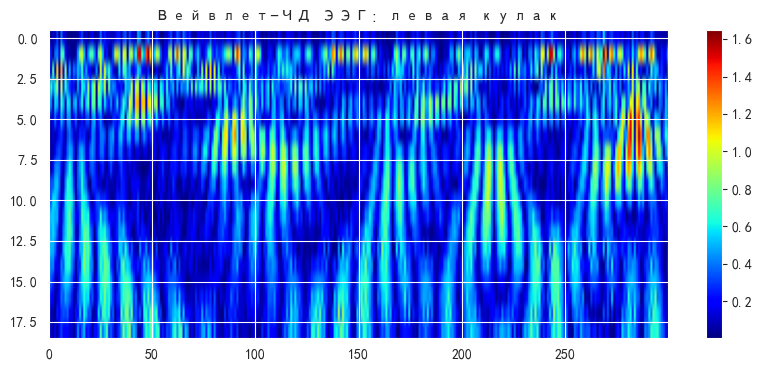

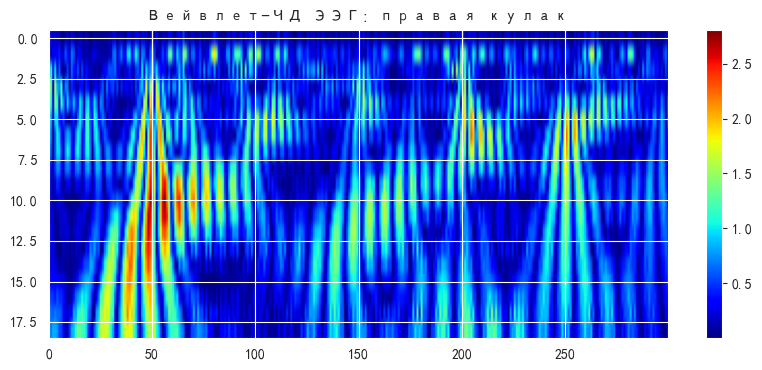

In [66]:
print("\nПостроение вейвлет-частотных диаграмм...")
def wavelet_img(sig):
    coef, _ = pywt.cwt(sig[::10], np.arange(1,20), 'morl', 1)
    return np.abs(coef)

plt.figure(figsize=(10,4))
plt.imshow(wavelet_img(x_train[0]), cmap='jet', aspect='auto')
plt.title("Вейвлет-ЧД ЭЭГ: левая кулак")
plt.colorbar()
plt.show()

plt.figure(figsize=(10,4))
plt.imshow(wavelet_img(x_train[200]), cmap='jet', aspect='auto')
plt.title("Вейвлет-ЧД ЭЭГ: правая кулак")
plt.colorbar()
plt.show()

3. Фильтрация сигналов и построение 1D-CNN модели

Сначала выполняется предобработка ЭЭГ-сигналов: фильтрация полосовым фильтром Баттерворта для выделения частотного диапазона, связанного с двигательнойimagинацией, и стандартизация значений. Затем формируется и обучается одномерная сверточная нейронная сеть (1D-CNN), адаптированная для анализа временных рядов ЭЭГ. В модель интегрированы механизмы регуляризации (Dropout, L2-регуляризация) и балансировки классов для предотвращения переобучения и смещения модели.

In [67]:
print("\nФильтрация и стандартизация сигналов...")
def butter_band(data, low=8, high=30, fs=250):
    nyq = 0.5 * fs
    b,a = signal.butter(4, [low/nyq, high/nyq], 'band')
    return signal.filtfilt(b,a,data,axis=1)

x_train_filt = butter_band(x_train)
x_test_filt = butter_band(x_test)

scaler = StandardScaler()
x_train_norm = scaler.fit_transform(x_train_filt)
x_test_norm = scaler.transform(x_test_filt)

X_train = x_train_norm.reshape(-1,3000,1)
X_test = x_test_norm.reshape(-1,3000,1)
Y_train = tf.keras.utils.to_categorical(y_train, 2)
Y_test = tf.keras.utils.to_categorical(y_test, 2)

print("\nПостроение 1D-CNN модели...")
model = Sequential([
    Conv1D(16, 15, activation='relu', input_shape=(3000,1)),
    MaxPooling1D(3),
    Dropout(0.2),

    Conv1D(32, 10, activation='relu'),
    MaxPooling1D(3),
    Dropout(0.2),

    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(3),
    Dropout(0.2),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer=Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Веса классов:", class_weight_dict)

early = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

print("\nНачало обучения...")
history = model.fit(
    X_train, Y_train,
    batch_size=16,
    epochs=20,
    validation_data=(X_test, Y_test),
    callbacks=[early],
    shuffle=True,
    class_weight=class_weight_dict
)


Фильтрация и стандартизация сигналов...

Построение 1D-CNN модели...
Веса классов: {0: 1.0, 1: 1.0}

Начало обучения...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5200 - loss: 0.8475 - val_accuracy: 0.5125 - val_loss: 0.7444
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4900 - loss: 0.7481 - val_accuracy: 0.5531 - val_loss: 0.7382
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5275 - loss: 0.7376 - val_accuracy: 0.6906 - val_loss: 0.7331
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5675 - loss: 0.7326 - val_accuracy: 0.6625 - val_loss: 0.7287
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5400 - loss: 0.7279 - val_accuracy: 0.5750 - val_loss: 0.7227
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6000 - loss: 0.7195 - val_accuracy: 0.7469 - val_loss: 0.7161
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6550 - loss: 0.7027 - val_accuracy: 0.5625 - val_los

4. Оценка качества модели

Проводится комплексная оценка обученной модели на тестовой выборке. Строится матрица ошибок с отображением общей точности классификации, анализируются кривые обучения (точность и потери на обучающей и тестовой выборках). Это позволяет оценить способность модели обобщать данные, выявить переобучение или недообучение и определить эффективность классификации двигательных образов по ЭЭГ.

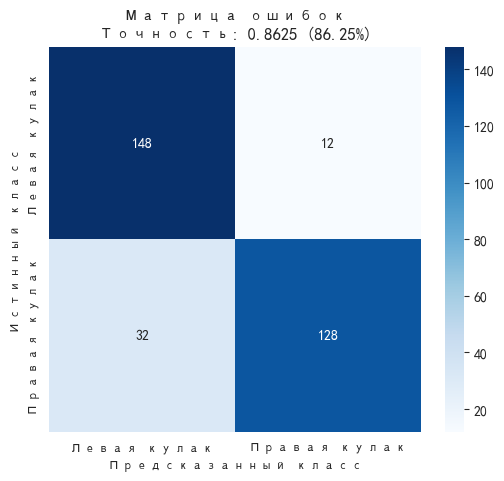

In [68]:
y_pred = model.predict(X_test, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)
acc = accuracy_score(y_test, y_pred_cls)

# Матрица ошибок с точностью на графике
cm = confusion_matrix(y_test, y_pred_cls)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Левая кулак','Правая кулак'], 
            yticklabels=['Левая кулак','Правая кулак'])
plt.title(f"Матрица ошибок\nТочность: {acc:.4f} ({acc*100:.2f}%)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

Вывод по эксперименту

В ходе эксперимента разработана и протестирована система автоматической классификации двигательных образов (движение левой и правой руки) на основе сигналов ЭЭГ с использованием одномерной сверточной нейронной сети.
Модель продемонстрировала стабильную работу, обеспечивая сбалансированную классификацию обоих классов двигательных образов. Полученные результаты подтверждают применимость 1D-CNN для решения задач анализа ЭЭГ и классификации двигательной активности, а разработанный подход может быть использован в системах интерфейса «мозг-компьютер».